# Lane Detection: Region of Interest

A camera mounted in a car sees far more than the road: sky, trees, signs, other cars and guardrails. Lane markings, however, can only appear in a fixed area of the image, the road directly in front of the car. A **region of interest (ROI)** is a polygon around that area. Everything outside it is set to black, so later steps only have to deal with pixels that can actually belong to a lane.

This notebook combines the ROI with the white colour mask from the colour notebook: a pixel is kept only if it is **white** (R, G and B all at or above a threshold) **and** lies **inside the ROI**.

**What it does:**
1. Loads the colour road image `image_lane_c.jpg`.
2. Defines the ROI as a **trapezoid**: wide at the bottom near the car, narrow near the horizon where the lane lines meet.
3. Draws the ROI on the image and builds a binary ROI mask with `cv2.fillPoly`.
4. Builds the white colour mask for `WHITE_THRESHOLD` and combines it with the ROI.
5. Shows the effect of the ROI: white pixels without the ROI, the ROI mask, and white pixels inside the ROI.
6. Compares several thresholds (`COMPARE_THRESHOLDS`: 220, 200, 180) with and without the ROI.
7. Saves the ROI overlay as `image_lane_roi_overlay.jpg`, the result for `WHITE_THRESHOLD` as `image_lane_roi.jpg` and each comparison result as `image_lane_roi_<threshold>.jpg`.

**How it is implemented:**
- The ROI corners are given as **fractions of the image width and height**, not pixels, so the same ROI works for images of any resolution from the same camera.
- The ROI mask and the white mask are both boolean arrays, so combining them is a single `&`.
- The image is loaded with `cv2.imread` (**BGR**) and converted to **RGB** once; it is converted back to BGR only for saving.
- All parameters are named constants in the configuration cell, and missing files and failed saves raise clear errors.

## 1. Imports

- `cv2` (OpenCV): image I/O, colour conversion and polygon drawing
- `matplotlib`: displaying images
- `numpy`: array operations
- `pathlib`: file paths that work on any OS

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Configuration

`ROI_VERTICES` lists the four corners of the trapezoid as `(x, y)` fractions, where `(0, 0)` is the top-left and `(1, 1)` is the bottom-right corner of the image. They are ordered **bottom-left, top-left, top-right, bottom-right**, so the polygon is drawn without crossing lines.

- The **bottom edge** spans almost the full width, because both lane lines are far apart right in front of the car.
- The **top edge** is narrow and sits just below the horizon (about 62% of the image height), where both lane lines meet. Placing it slightly below the horizon keeps the cars ahead out of the ROI.

`WHITE_THRESHOLD` is the minimum value that each of R, G and B must reach for a pixel to count as white. We use 220, the best value from the colour notebook. `COMPARE_THRESHOLDS` lists the thresholds compared in section 6.

In [2]:
INPUT_PATH = Path("image_lane_c.jpg")
OUTPUT_PATH = INPUT_PATH.with_name("image_lane_roi.jpg")
OVERLAY_PATH = INPUT_PATH.with_name("image_lane_roi_overlay.jpg")

# Trapezoid corners as (x, y) fractions of width and height:
# bottom-left, top-left, top-right, bottom-right
ROI_VERTICES = ((0.10, 1.00), (0.46, 0.62), (0.54, 0.62), (0.95, 1.00))

WHITE_THRESHOLD = 220  # 0-255: minimum value for every channel (R, G and B)
COMPARE_THRESHOLDS = (220, 200, 180)  # thresholds compared side by side in section 6

## 3. Load the image

`cv2.imread` returns `None` instead of raising an error when a file is missing, so we check for that.

> ⚠️ OpenCV loads images in **BGR** order. We convert to **RGB** right away, so channel 0 is red, 1 is green and 2 is blue in all the following code.

In [3]:
image_bgr = cv2.imread(str(INPUT_PATH), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise FileNotFoundError(f"Could not read image: {INPUT_PATH.resolve()}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

height, width, channels = image_rgb.shape
print(f"Colour image: {width}x{height} px, {channels} channels, dtype={image_rgb.dtype}")

Colour image: 960x540 px, 3 channels, dtype=uint8


## 4. Build the region of interest

`roi_polygon` converts the fractional corners into pixel coordinates. `roi_mask` then fills that polygon with `cv2.fillPoly`: every pixel inside becomes 255 and every pixel outside stays 0. We turn the result into a boolean array so it can be combined with other masks.

To check that the trapezoid fits the road, we first draw its outline on the image with `cv2.polylines`.

ROI corners in pixels (x, y): [[96, 539], [441, 334], [518, 334], [911, 539]]
ROI covers 92,246 of 518,400 pixels (17.79% of the image)


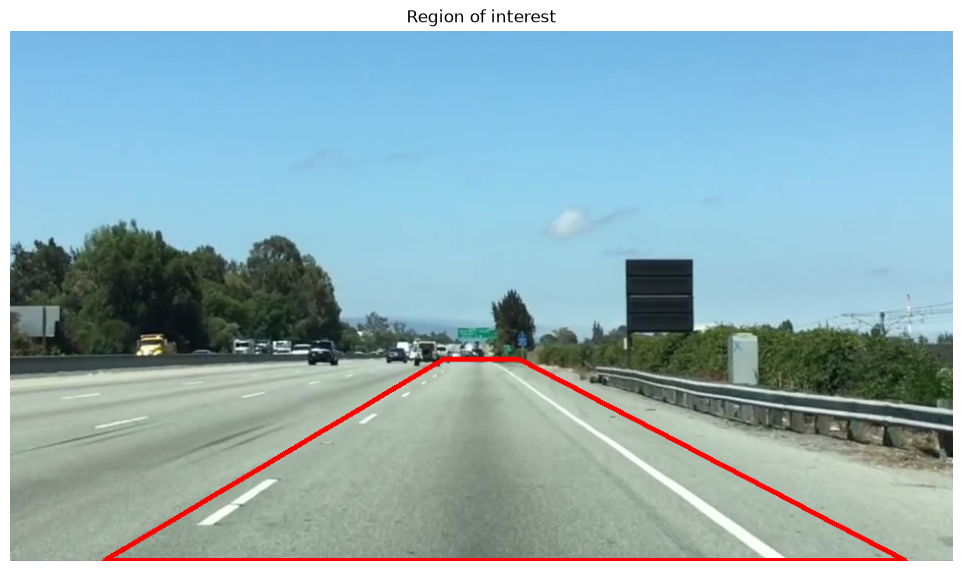

In [4]:
def roi_polygon(shape: tuple[int, ...], vertices: tuple[tuple[float, float], ...]) -> np.ndarray:
    """Convert (x, y) fractions into an int32 array of pixel coordinates for OpenCV."""
    h, w = shape[:2]
    return np.array([(round(x * (w - 1)), round(y * (h - 1))) for x, y in vertices], dtype=np.int32)


def roi_mask(shape: tuple[int, ...], vertices: tuple[tuple[float, float], ...]) -> np.ndarray:
    """Return a boolean mask that is True inside the ROI polygon."""
    mask = np.zeros(shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [roi_polygon(shape, vertices)], 255)
    return mask.astype(bool)


polygon = roi_polygon(image_rgb.shape, ROI_VERTICES)
roi = roi_mask(image_rgb.shape, ROI_VERTICES)

image_overlay = image_rgb.copy()
cv2.polylines(image_overlay, [polygon], isClosed=True, color=(255, 0, 0), thickness=3)

print("ROI corners in pixels (x, y):", polygon.tolist())
print(f"ROI covers {int(roi.sum()):,} of {roi.size:,} pixels ({roi.mean():.2%} of the image)")

fig, ax = plt.subplots(figsize=(10, 5.6), layout="constrained")
ax.imshow(image_overlay)
ax.set_title("Region of interest")
ax.axis("off")
plt.show()

## 5. Combine the white mask with the ROI

`white_mask` is the same rule as in the colour notebook: a pixel is white only if **all** channels are at or above the threshold. The final mask keeps a pixel only if it is white **and** inside the ROI:

$$\text{keep} = \text{white} \land \text{ROI}$$

`apply_mask` keeps the original colours of those pixels and sets everything else to black.

Threshold: 220 (per channel)
White pixels in the whole image: 3,102
White pixels inside the ROI:     2,711 (87.4% of all white pixels)
Removed by the ROI:              391


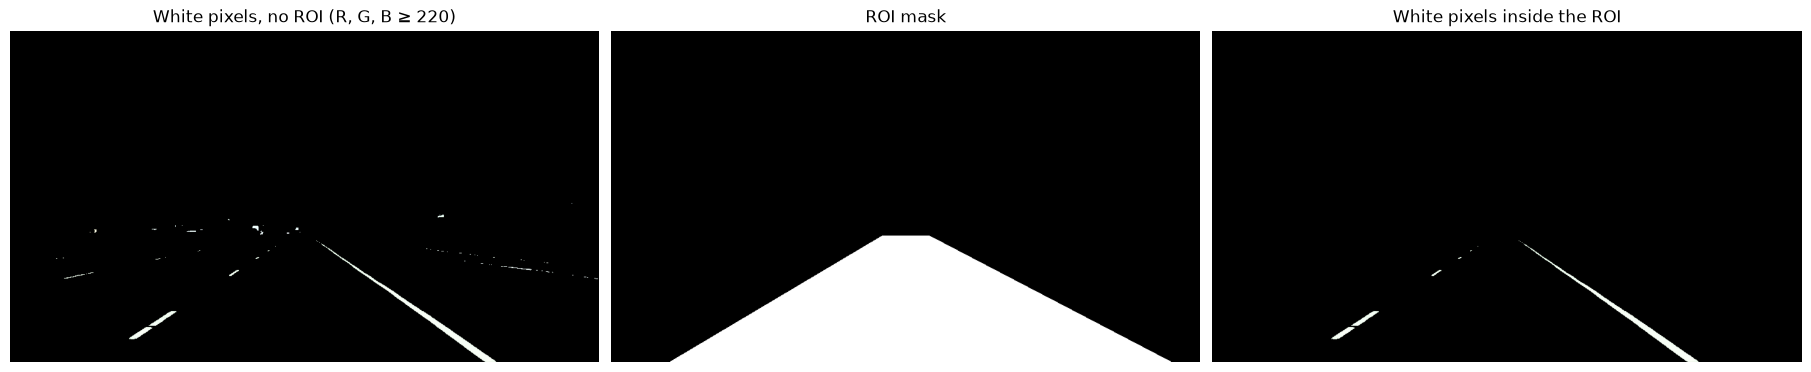

In [5]:
def white_mask(image_rgb: np.ndarray, threshold: int) -> np.ndarray:
    """Return a boolean mask that is True where every colour channel is >= threshold."""
    return np.all(image_rgb >= threshold, axis=-1)


def apply_mask(image_rgb: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Keep the pixels where mask is True and set all others to black."""
    return np.where(mask[..., np.newaxis], image_rgb, 0).astype(np.uint8)


white = white_mask(image_rgb, WHITE_THRESHOLD)
lanes = white & roi
image_lanes = apply_mask(image_rgb, lanes)

total_white, kept = int(white.sum()), int(lanes.sum())
print(f"Threshold: {WHITE_THRESHOLD} (per channel)")
print(f"White pixels in the whole image: {total_white:,}")
print(f"White pixels inside the ROI:     {kept:,} ({kept / total_white:.1%} of all white pixels)")
print(f"Removed by the ROI:              {total_white - kept:,}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), layout="constrained")

axes[0].imshow(apply_mask(image_rgb, white))
axes[0].set_title(f"White pixels, no ROI (R, G, B ≥ {WHITE_THRESHOLD})")

axes[1].imshow(roi, cmap="gray")
axes[1].set_title("ROI mask")

axes[2].imshow(image_lanes)
axes[2].set_title("White pixels inside the ROI")

for ax in axes:
    ax.axis("off")

plt.show()

## 6. Compare several thresholds

`compare_thresholds` gives one row per threshold:
- **left:** the white pixels in the whole image
- **right:** the white pixels that remain inside the ROI, with the ROI outline drawn in red

It returns a dictionary that maps each threshold to its ROI result, so you can reuse the images later. Change `COMPARE_THRESHOLDS` or `ROI_VERTICES` in section 2 to try other values.

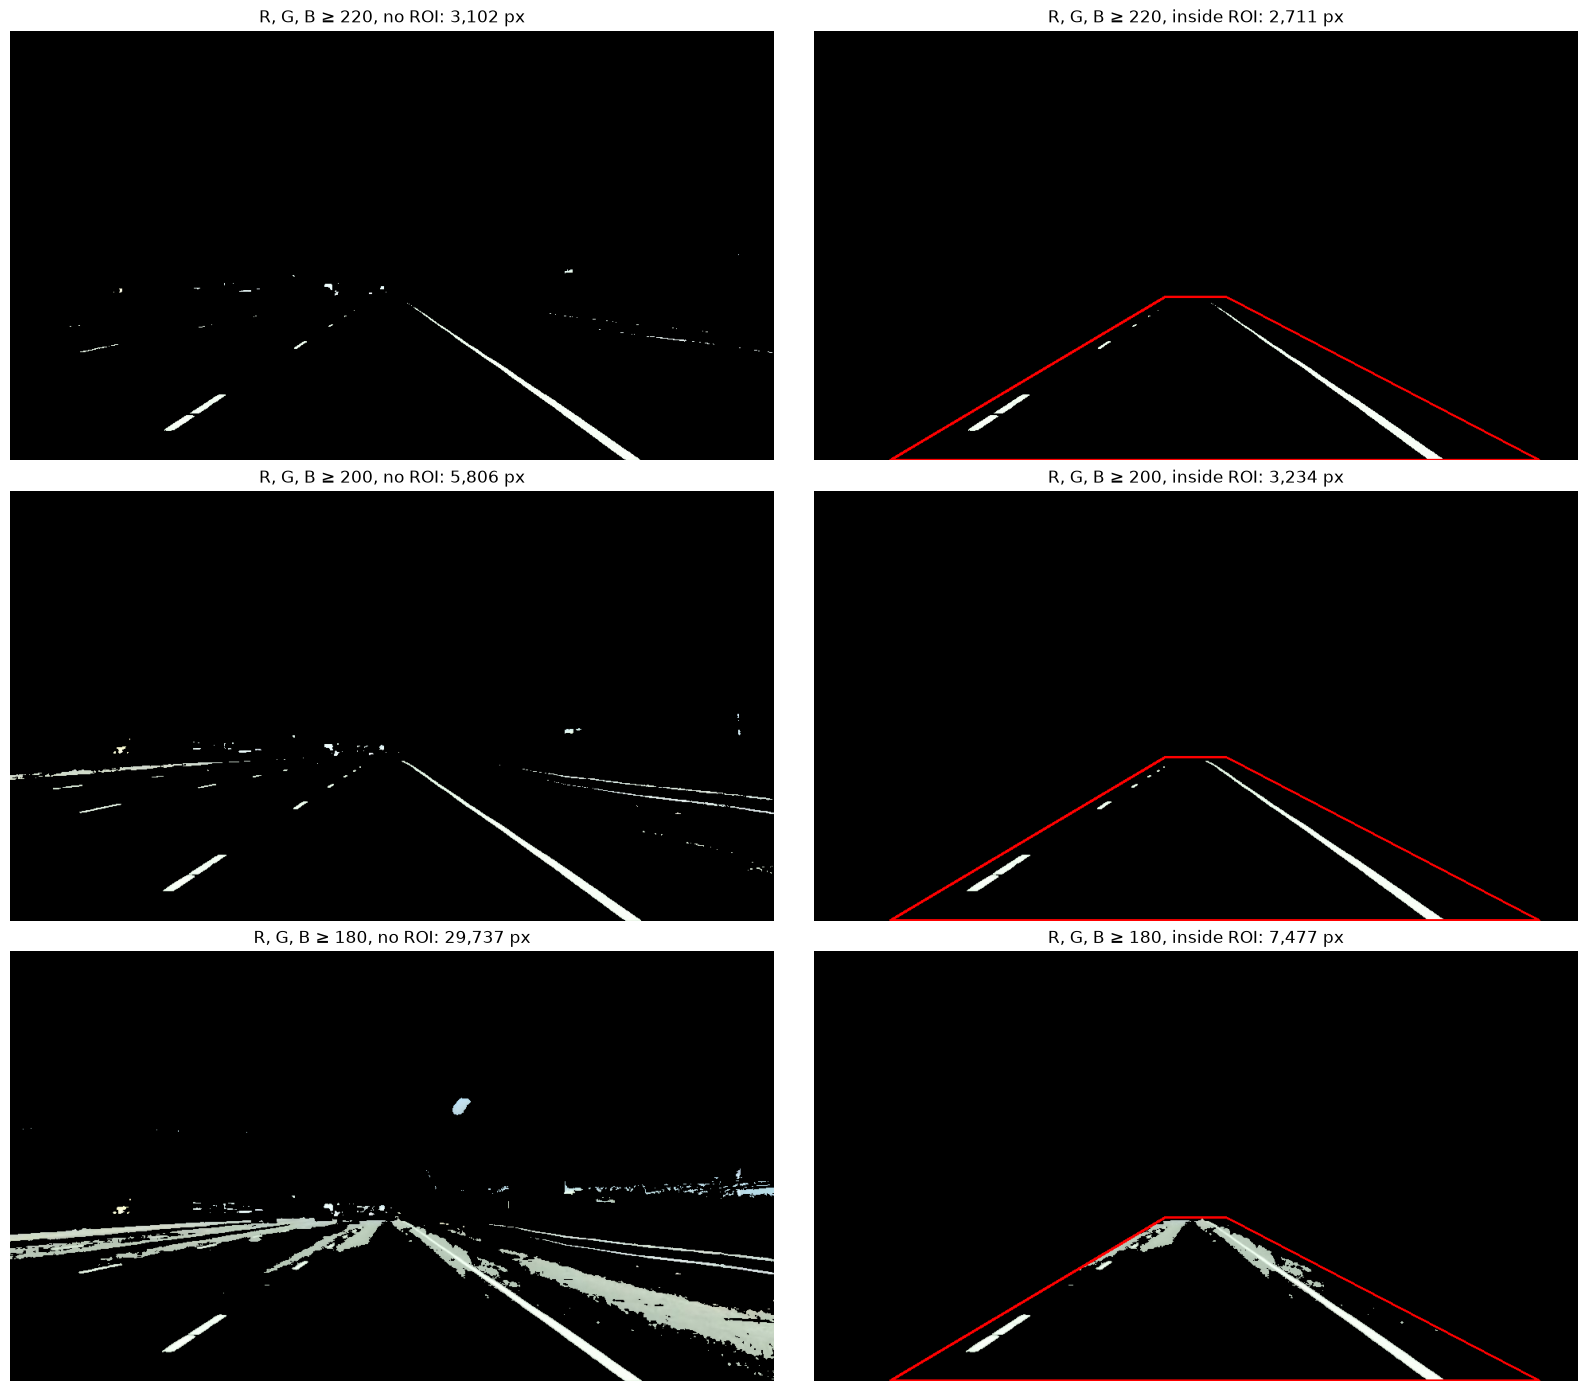

In [6]:
def compare_thresholds(
    image_rgb: np.ndarray,
    roi: np.ndarray,
    polygon: np.ndarray,
    thresholds: tuple[int, ...] = (220, 200, 180),
) -> dict[int, np.ndarray]:
    """Plot white pixels without and with the ROI for each threshold and return the ROI results."""
    results: dict[int, np.ndarray] = {}
    fig, axes = plt.subplots(
        len(thresholds), 2, figsize=(16, 4.6 * len(thresholds)), layout="constrained", squeeze=False
    )

    for (ax_full, ax_roi), threshold in zip(axes, thresholds):
        white = white_mask(image_rgb, threshold)
        lanes = white & roi
        results[threshold] = apply_mask(image_rgb, lanes)

        ax_full.imshow(apply_mask(image_rgb, white))
        ax_full.set_title(f"R, G, B ≥ {threshold}, no ROI: {int(white.sum()):,} px")

        roi_view = results[threshold].copy()
        cv2.polylines(roi_view, [polygon], isClosed=True, color=(255, 0, 0), thickness=2)
        ax_roi.imshow(roi_view)
        ax_roi.set_title(f"R, G, B ≥ {threshold}, inside ROI: {int(lanes.sum()):,} px")

        for ax in (ax_full, ax_roi):
            ax.axis("off")

    plt.show()
    return results


threshold_results = compare_thresholds(image_rgb, roi, polygon, COMPARE_THRESHOLDS)

### Results for 220, 200 and 180

> These notes are for `image_lane_c.jpg` with the thresholds 220, 200 and 180 and the ROI from section 2. If you change `COMPARE_THRESHOLDS`, `ROI_VERTICES` or the image, look at the new plots and read them the same way.

| Threshold | Pixels without ROI | Pixels inside ROI | Removed by ROI | Observation |
|---|---|---|---|---|
| 220 | 3,102 | 2,711 | 13% | Clean lanes. The ROI removes the last noise: the dots near the horizon and the faint line along the right road edge. |
| 200 | 5,806 | 3,234 | 44% | Clean lanes, with more of the distant dashed markings than at 220. The neighbouring lanes and the guardrail, which were the problem at 200 before, are outside the ROI. |
| 180 | 29,737 | 7,477 | 75% | The ROI removes most of the noise, but light asphalt inside the ROI still passes, near the horizon and next to the right lane line. |

**What the ROI changes:** without the ROI, 200 was too noisy because of the guardrail and neighbouring lanes, so the threshold had to be strict. The ROI removes exactly those areas, because they lie outside the road in front of the car. That means the **threshold can be lower**, which keeps more of the faint, distant lane paint. The ROI can't help with noise **inside** the trapezoid, which is why 180 is still too low.

**Best value for this image with the ROI: about 200.** It keeps the most lane paint while the result stays clean. 220 also works, but loses some of the distant dashes. Below about 200 the asphalt inside the ROI starts to pass.

**Limits of a fixed ROI:** the trapezoid assumes the camera is mounted in the same place and the road is straight and flat. In curves, on hills or during a lane change, parts of the lane can move outside the ROI, so its corners are a trade-off between removing noise and not cutting off real lane lines.

## 7. Save the results

We save the ROI overlay, the result for `WHITE_THRESHOLD` and one image per value in `COMPARE_THRESHOLDS`, e.g. `image_lane_roi_200.jpg`.

> ⚠️ `cv2.imwrite` expects **BGR**, so we convert back from RGB before saving. It returns `False` when saving fails, so we check the result.

In [7]:
def save_rgb(path: Path, image_rgb: np.ndarray) -> None:
    """Save an RGB image with OpenCV, raising an error if it fails."""
    if not cv2.imwrite(str(path), cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)):
        raise OSError(f"Could not write image: {path.resolve()}")
    print(f"Saved {path.resolve()}")


save_rgb(OVERLAY_PATH, image_overlay)
save_rgb(OUTPUT_PATH, image_lanes)

for threshold, result in threshold_results.items():
    save_rgb(INPUT_PATH.with_name(f"image_lane_roi_{threshold}.jpg"), result)

Saved /workspaces/ml-autonomous-systems/lane_detection_region_of_interest/image_lane_roi_overlay.jpg
Saved /workspaces/ml-autonomous-systems/lane_detection_region_of_interest/image_lane_roi.jpg
Saved /workspaces/ml-autonomous-systems/lane_detection_region_of_interest/image_lane_roi_220.jpg
Saved /workspaces/ml-autonomous-systems/lane_detection_region_of_interest/image_lane_roi_200.jpg
Saved /workspaces/ml-autonomous-systems/lane_detection_region_of_interest/image_lane_roi_180.jpg
